# Third-Party Algorithm Comparison

Small, optional benchmark notebook for comparing `torchbvh` with other point-cloud algorithms. It is not part of the package test suite. Missing optional packages are reported as skipped rows.

## Optional Installs

Uncomment only the packages you want to compare in this notebook environment.

In [ ]:
# Optional notebook installs. Uncomment the packages you want.
# %pip install scipy
# %pip install torch-cluster
# %pip install cupy-knn[cuda12x]
# torch_fpsample must be installed from source (not on PyPI):
# %pip install git+https://github.com/leonardodalinky/pytorch_fpsample.git
# On Windows, clone the repo, add /std:c++17 /Zc:__cplusplus to extra_compile_args in setup.py, then:
# %pip install --no-build-isolation <path-to-clone>
# %pip install fpsample
# %pip install pandas


## Setup

In [14]:
from __future__ import annotations

import json
import math
from pathlib import Path

import torch
import torchbvh as ibvh
import torchbvh._C as ibvh_C

from benchmarks.benchmark_helpers import (
    SkipBackend,
    dense_cdist_skip,
    environment as benchmark_environment,
    make_random_points_queries,
    optional_module,
    patch_cupy_knn_compile_flags,
    run_backends,
    show_rows,
    sync,
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 0
BATCH_SIZE = 16
N_POINTS = 10000
N_QUERIES = 10000
DIM = 3
K = 8
FPS_TARGET = int(N_POINTS * 0.25)
QUALITY_QUERIES = 512
WARMUP = 5
ITERS = 5
CDIST_MAX_ELEMENTS = 300_000_000
OUTPUT_JSON = Path("artifacts/third_party_algorithm_comparison.json")


def make_data() -> tuple[torch.Tensor, torch.Tensor]:
    return make_random_points_queries(
        device=DEVICE,
        seed=SEED,
        batch_size=BATCH_SIZE,
        n_points=N_POINTS,
        n_queries=N_QUERIES,
        dim=DIM,
    )


def environment() -> dict:
    return benchmark_environment(ibvh, ibvh_C, DEVICE)


points, queries = make_data()
environment()


{'python': '3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]',
 'python_executable': 'c:\\Users\\Rob.Hart-Villamil\\Documents\\python_envs\\ml\\Scripts\\python.exe',
 'platform': 'Windows-10-10.0.19045-SP0',
 'torch': '2.10.0+cu126',
 'torch_cuda': '12.6',
 'torchbvh': 'C:\\Users\\Rob.Hart-Villamil\\Documents\\python_project_files\\pytorch_implicitbvh\\torchbvh\\__init__.py',
 'torchbvh_extension': 'C:\\Users\\Rob.Hart-Villamil\\Documents\\python_project_files\\pytorch_implicitbvh\\torchbvh\\_C.cp313-win_amd64.pyd',
 'device': 'cuda',
 'gpu': 'NVIDIA RTX 3500 Ada Generation Laptop GPU'}

## k-NN Comparison

Backends return neighbor indices shaped `(B, N_QUERIES, K)`. Each adapter runs explicit warmup calls before timed iterations so CUDA kernel compilation, allocator setup, index construction caches, and one-time library initialization are kept out of the reported timings where the backend allows it. CPU rows include GPU/CPU transfer because the notebook starts from GPU-resident tensors. Quality is measured against exact PyTorch brute-force distances.

In [7]:
def knn_implicit_bvh() -> torch.Tensor:
    if DEVICE != "cuda":
        raise SkipBackend("torchbvh k-NN requires CUDA")
    bvh = ibvh.build_bvh(points)
    try:
        indices, _distances = ibvh.query_knn(bvh, queries, K)
        return indices
    finally:
        ibvh.destroy_bvh(bvh)


def knn_torch_cdist() -> torch.Tensor:
    return torch.cdist(queries, points).topk(K, largest=False).indices


def knn_scipy_ckdtree() -> torch.Tensor:
    scipy_spatial = optional_module("scipy.spatial")
    rows = []
    for p, q in zip(points.detach().cpu().numpy(), queries.detach().cpu().numpy()):
        _distances, indices = scipy_spatial.cKDTree(p).query(q, k=K)
        rows.append(torch.as_tensor(indices, dtype=torch.long))
    return torch.stack(rows).to(points.device)


def knn_torch_cluster() -> torch.Tensor:
    mod = optional_module("torch_cluster")
    if not hasattr(mod, "knn"):
        raise SkipBackend("torch_cluster.knn was not found")

    rows = []
    for p, q in zip(points, queries):
        query_ids, neighbor_ids = mod.knn(p, q, K).reshape(2, N_QUERIES, K)
        neighbor_ids = torch.gather(neighbor_ids, 1, query_ids.argsort(dim=1, stable=True))
        distances = (q.unsqueeze(1) - p[neighbor_ids]).square().sum(dim=-1)
        rows.append(torch.gather(neighbor_ids, 1, distances.argsort(dim=1)))
    return torch.stack(rows)


def knn_cupy_knn() -> torch.Tensor:
    if DEVICE != "cuda" or DIM != 3:
        raise SkipBackend("cupy-knn requires CUDA and 3D points")
    cp = optional_module("cupy")
    cupy_knn = optional_module("cupy_knn")
    patch_cupy_knn_compile_flags(cp, optional_module("cupy_knn.lbvh_index"))

    rows = []
    for p, q in zip(points, queries):
        p_cp = cp.from_dlpack(torch.utils.dlpack.to_dlpack(p.contiguous()))
        q_cp = cp.from_dlpack(torch.utils.dlpack.to_dlpack(q.contiguous()))
        index = cupy_knn.LBVHIndex(leaf_size=32, compact=True, shrink_to_fit=True, sort_queries=True)
        index.build(p_cp)
        index.prepare_knn_default(K)
        indices, _distances, _count = index.query_knn(q_cp)
        rows.append(torch.utils.dlpack.from_dlpack(indices).long())
    return torch.stack(rows)


def knn_quality(indices: torch.Tensor) -> dict:
    n_quality = min(N_QUERIES, QUALITY_QUERIES)
    q = queries[:, :n_quality]
    idx = indices[:, :n_quality]
    gathered = torch.gather(points.unsqueeze(1).expand(-1, n_quality, -1, -1), 2, idx.unsqueeze(-1).expand(-1, -1, -1, DIM))
    returned = (q.unsqueeze(2) - gathered).square().sum(dim=-1).sort(dim=-1).values
    exact = torch.cdist(q, points).square().topk(K, largest=False).values
    error = (returned - exact).abs()
    return {
        "shape": "x".join(map(str, indices.shape)),
        "max_distance_error": float(error.max().detach().cpu()),
        "mean_distance_error": float(error.mean().detach().cpu()),
        "mean_kth_distance": float(returned[..., -1].mean().detach().cpu()),
        "quality_queries": n_quality,
    }


KNN_BACKENDS = {
    "torchbvh": knn_implicit_bvh,
    "torch_cdist": knn_torch_cdist,
    "scipy_ckdtree": knn_scipy_ckdtree,
    "torch_cluster": knn_torch_cluster,
    "cupy_knn": knn_cupy_knn,
}

knn_rows = show_rows(run_backends(
    KNN_BACKENDS,
    "knn",
    knn_quality,
    warmup=WARMUP,
    iters=ITERS,
    skip_fn=lambda label: dense_cdist_skip(BATCH_SIZE, N_QUERIES, N_POINTS, CDIST_MAX_ELEMENTS) if label == "torch_cdist" else None,
))


,group,backend,status,warmup_runs,timed_runs,mean_ms,min_ms,max_ms,median_ms,timings_ms,...,peak_cuda_mib,cuda_event_mean_ms,cuda_event_min_ms,cuda_event_max_ms,cuda_event_median_ms,shape,max_distance_error,mean_distance_error,mean_kth_distance,quality_queries
0,knn,torchbvh,ok,10,5,9.74528,7.6197,11.3475,11.0343,"[11.087299790233374, 7.63759994879365, 11.0343...",...,11.168945,9.509478,7.404544,11.197440,10.669056,1x10000x8,5.474431e-07,6.489292e-08,0.003508,512
1,knn,torch_cdist,ok,10,5,14.96286,14.6639,15.3022,14.9343,"[15.302199870347977, 15.184199903160334, 14.66...",...,407.168945,14.442291,13.919232,14.848000,14.539776,1x10000x8,5.474431e-07,6.489292e-08,0.003508,512
2,knn,scipy_ckdtree,ok,10,5,23.44342,19.1949,26.6752,23.0888,"[19.194900058209896, 22.621700074523687, 23.08...",...,9.944824,23.340448,19.073183,26.569281,22.983200,1x10000x8,5.474431e-07,6.489292e-08,0.003508,512
3,knn,torch_cluster,ok,10,5,6.87926,6.4940,7.4758,6.5560,"[7.349899969995022, 6.555999629199505, 7.47580...",...,13.074219,6.653747,6.287360,7.251968,6.318080,1x10000x8,5.474431e-07,6.489292e-08,0.003508,512
4,knn,cupy_knn,ok,10,5,4.10202,3.4963,5.5179,3.5434,"[4.450500011444092, 3.5433997400105, 3.4962999...",...,10.555176,3.635814,3.113984,5.143552,3.144704,1x10000x8,5.474431e-07,6.489292e-08,0.003508,512


## FPS Comparison

Backends return selected anchor indices shaped `(B, FPS_TARGET)`.

In [15]:
def fps_implicit_bvh() -> torch.Tensor:
    if DEVICE != "cuda":
        raise SkipBackend("torchbvh FPS requires CUDA")
    return ibvh.fps(points, FPS_TARGET).indices


def fps_torch_fpsample() -> torch.Tensor:
    mod = optional_module("torch_fpsample")
    output = mod.sample(points.detach().cpu().contiguous(), FPS_TARGET, h=7, start_idx=0)
    return torch.as_tensor(output[-1] if isinstance(output, tuple) else output, dtype=torch.long, device=points.device)


def fps_fpsample() -> torch.Tensor:
    mod = optional_module("fpsample")
    if not hasattr(mod, "fps_sampling"):
        raise SkipBackend("fpsample.fps_sampling was not found")
    rows = [torch.as_tensor(mod.fps_sampling(sample, FPS_TARGET, start_idx=0), dtype=torch.long) for sample in points.detach().cpu().numpy()]
    return torch.stack(rows).to(points.device)


def fps_quality(indices: torch.Tensor) -> dict:
    anchors = torch.gather(points, 1, indices.unsqueeze(-1).expand(-1, -1, DIM))
    nearest = torch.cdist(points, anchors).amin(dim=-1)
    return {
        "shape": "x".join(map(str, indices.shape)),
        "min_unique": min(row.unique().numel() for row in indices.detach().cpu()),
        "coverage_radius": float(nearest.max().detach().cpu()),
        "mean_nearest_anchor_distance": float(nearest.mean().detach().cpu()),
    }


FPS_BACKENDS = {
    "torchbvh": fps_implicit_bvh,
    "torch_fpsample": fps_torch_fpsample,
    "fpsample": fps_fpsample,
}

fps_rows = show_rows(run_backends(FPS_BACKENDS, "fps", fps_quality, warmup=WARMUP, iters=ITERS))


,group,backend,status,warmup_runs,timed_runs,mean_ms,min_ms,max_ms,median_ms,timings_ms,cuda_event_timings_ms,peak_cuda_mib,cuda_event_mean_ms,cuda_event_min_ms,cuda_event_max_ms,cuda_event_median_ms,shape,min_unique,coverage_radius,mean_nearest_anchor_distance
0,fps,torchbvh,ok,5,5,25.55620,21.1032,27.2614,26.3214,"[26.321399956941605, 27.261400129646063, 26.82...","[26.074687957763672, 27.073759078979492, 26.59...",55.580078,25.344512,20.918880,27.073759,26.074688,16x2500,2500,0.055222,0.02717
1,fps,torch_fpsample,ok,5,5,52.56000,36.9916,67.8882,56.7111,"[36.99159994721413, 39.52480014413595, 56.7111...","[36.85955047607422, 39.4185905456543, 56.58076...",43.367676,52.439443,36.859550,67.776962,56.580769,16x2500,2500,0.055222,0.02717
2,fps,fpsample,ok,5,5,838.37714,832.7160,845.2706,838.8462,"[835.8216001652181, 832.7160002663732, 839.231...","[835.65966796875, 832.5672607421875, 839.07623...",43.367676,838.232056,832.567261,845.148193,838.708923,16x2500,2500,0.055222,0.02717


## k-NN Scaling Sweep

Run the optional k-NN backends at equal source/query sizes and plot query throughput. The dense `torch.cdist` backend is skipped when its full `(B, Q, N)` distance matrix would exceed the configured element guard.


,group,backend,status,warmup_runs,timed_runs,mean_ms,min_ms,max_ms,median_ms,timings_ms,cuda_event_timings_ms,peak_cuda_mib,cuda_event_mean_ms,cuda_event_min_ms,cuda_event_max_ms,cuda_event_median_ms,shape,n,queries_per_second,reason
0,knn_sweep,torchbvh,ok,10,5,5.50996,3.7593,11.3119,4.1564,"[4.511700011789799, 11.311899870634079, 4.1563...","[3.118079900741577, 6.737919807434082, 3.11910...",8.994141,3.842458,3.106816,6.737920,3.119104,1x1000x8,1000,1.814895e+05,NaN
1,knn_sweep,torch_cdist,ok,10,5,1.61026,1.5886,1.6533,1.5992,"[1.6533001326024532, 1.5981001779437065, 1.612...","[1.411072015762329, 1.405951976776123, 1.41516...",14.208984,1.409638,1.405952,1.415168,1.408000,1x1000x8,1000,6.210177e+05,NaN
2,knn_sweep,scipy_ckdtree,ok,10,5,6.14976,3.4281,8.1594,6.8371,"[3.4281001426279545, 6.83709979057312, 7.74489...","[3.3177599906921387, 6.594560146331787, 6.6222...",8.869629,5.637939,3.317760,7.182336,6.594560,1x1000x8,1000,1.626080e+05,NaN
3,knn_sweep,torch_cluster,ok,10,5,1.60576,1.5589,1.7368,1.5675,"[1.7368001863360405, 1.6004997305572033, 1.567...","[1.5083520412445068, 1.4776320457458496, 1.458...",9.183594,1.471283,1.454080,1.508352,1.458176,1x1000x8,1000,6.227581e+05,NaN
4,knn_sweep,cupy_knn,ok,10,5,2.18916,2.0499,2.6472,2.0858,"[2.6471996679902077, 2.091200090944767, 2.0717...","[2.0736000537872314, 1.6250879764556885, 1.635...",8.930664,1.716224,1.612800,2.073600,1.634304,1x1000x8,1000,4.567962e+05,NaN
5,knn_sweep,torchbvh,ok,10,5,1.43754,1.3619,1.6177,1.4009,"[1.4245002530515194, 1.361900009214878, 1.4008...","[1.2451839447021484, 1.2462079524993896, 1.253...",11.398438,1.296384,1.244160,1.492992,1.246208,1x10000x8,10000,6.956329e+06,NaN
6,knn_sweep,torch_cdist,ok,10,5,14.80500,14.1646,15.2709,14.7299,"[15.2708999812603, 14.164600055664778, 14.7298...","[14.829567909240723, 13.917183876037598, 13.94...",407.398438,14.414643,13.917184,14.889984,14.491648,1x10000x8,10000,6.754475e+05,NaN
7,knn_sweep,scipy_ckdtree,ok,10,5,32.91366,29.6284,37.2120,33.1187,"[34.536899998784065, 29.62840022519231, 37.211...","[34.40143966674805, 29.555328369140625, 37.115...",10.174316,32.803642,29.555328,37.115585,32.953312,1x10000x8,10000,3.038252e+05,NaN
8,knn_sweep,torch_cluster,ok,10,5,6.70500,6.4120,7.6428,6.4613,"[7.642799988389015, 6.426899693906307, 6.46129...","[7.4352641105651855, 6.21670389175415, 6.25868...",13.303711,6.495437,6.196224,7.435264,6.258688,1x10000x8,10000,1.491424e+06,NaN
9,knn_sweep,cupy_knn,ok,10,5,4.66264,4.3270,5.8581,4.3572,"[4.356800112873316, 4.327000118792057, 5.85810...","[3.759104013442993, 3.734528064727783, 5.27052...",10.784668,4.061594,3.734528,5.270528,3.759104,1x10000x8,10000,2.144708e+06,NaN


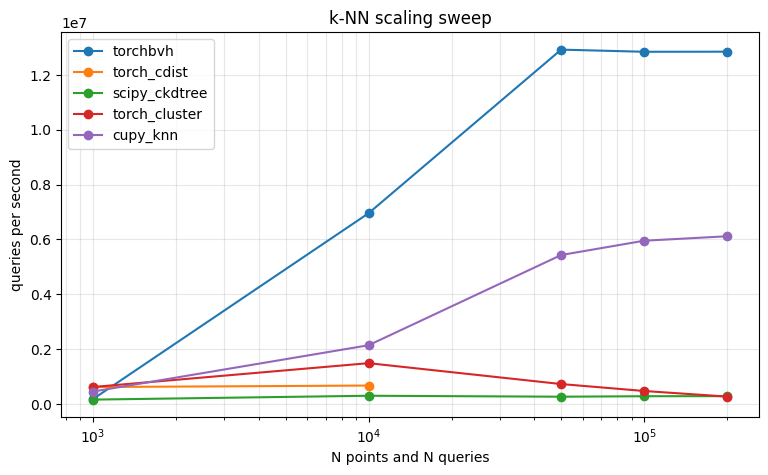

In [9]:
import matplotlib.pyplot as plt

SWEEP_SIZES = [1_000, 10_000, 50_000, 100_000, 200_000]
SWEEP_BATCH_SIZE = 1


def sweep_quality(indices: torch.Tensor) -> dict:
    return {"shape": "x".join(map(str, indices.shape))}


def run_knn_sweep() -> list[dict]:
    global BATCH_SIZE, N_POINTS, N_QUERIES, FPS_TARGET, points, queries

    saved = {name: globals()[name] for name in ("BATCH_SIZE", "N_POINTS", "N_QUERIES", "FPS_TARGET", "points", "queries")}
    rows = []
    try:
        for n in SWEEP_SIZES:
            BATCH_SIZE = SWEEP_BATCH_SIZE
            N_POINTS = N_QUERIES = n
            FPS_TARGET = int(N_POINTS * 0.25)
            points, queries = make_data()
            sync()

            size_rows = run_backends(
                KNN_BACKENDS,
                "knn_sweep",
                sweep_quality,
                warmup=WARMUP,
                iters=ITERS,
                skip_fn=lambda label, n=n: dense_cdist_skip(SWEEP_BATCH_SIZE, n, n, CDIST_MAX_ELEMENTS) if label == "torch_cdist" else None,
            )
            for row in size_rows:
                row["n"] = n
                row["queries_per_second"] = (SWEEP_BATCH_SIZE * n) / (row["mean_ms"] / 1000.0) if row.get("status") == "ok" else math.nan
            rows.extend(size_rows)
    finally:
        globals().update(saved)
        sync()
    return rows


sweep_rows = show_rows(run_knn_sweep())

fig, ax = plt.subplots(figsize=(9, 5))
for label in KNN_BACKENDS:
    series = [row for row in sweep_rows if row["backend"] == label and row.get("status") == "ok"]
    ax.plot([row["n"] for row in series], [row["queries_per_second"] for row in series], marker="o", label=label)

ax.set_xlabel("N points and N queries")
ax.set_ylabel("queries per second")
ax.set_title("k-NN scaling sweep")
ax.set_xscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()


## FPS Scaling Sweep


,group,backend,status,warmup_runs,timed_runs,mean_ms,min_ms,max_ms,median_ms,timings_ms,cuda_event_timings_ms,peak_cuda_mib,cuda_event_mean_ms,cuda_event_min_ms,cuda_event_max_ms,cuda_event_median_ms,shape,n,m,m_ratio
0,fps_sweep,torchbvh,ok,5,5,6.20736,2.1712,11.8799,3.9742,"[2.171199768781662, 11.879900004714727, 9.8616...","[1.9353280067443848, 11.663840293884277, 9.451...",34.581055,5.931962,1.935328,11.663840,3.697664,1x10,1000,10,0.01
1,fps_sweep,torch_fpsample,ok,5,5,0.83042,0.5212,1.1429,0.7966,"[1.1428999714553356, 0.5211997777223587, 0.914...","[1.0711040496826172, 0.45772799849510193, 0.85...",34.486328,0.765747,0.457728,1.071104,0.734208,1x10,1000,10,0.01
2,fps_sweep,fpsample,ok,5,5,21.04358,0.3415,97.3376,0.3514,"[0.34899963065981865, 0.3415001556277275, 0.35...","[0.2805759906768799, 0.27955201268196106, 0.28...",34.486328,20.864409,0.279552,97.252350,0.288768,1x10,1000,10,0.01
3,fps_sweep,torchbvh,ok,5,5,17.35884,5.3956,33.8525,14.8914,"[33.85250037536025, 14.369700103998184, 5.3956...","[33.51478576660156, 14.141632080078125, 5.1558...",35.040527,16.293453,5.155808,33.514786,14.141632,1x50,5000,50,0.01
4,fps_sweep,torch_fpsample,ok,5,5,4.93082,3.1617,7.5631,4.4814,"[3.6942996084690094, 5.753600038588047, 4.4813...","[2.702336072921753, 5.566463947296143, 4.38374...",34.578125,4.363264,2.606080,6.557696,4.383744,1x50,5000,50,0.01
5,fps_sweep,fpsample,ok,5,5,1.34300,1.1539,1.6994,1.2603,"[1.2294999323785305, 1.260299701243639, 1.1539...","[1.1079679727554321, 1.1745280027389526, 1.085...",34.578125,1.254810,1.085440,1.604608,1.174528,1x50,5000,50,0.01
6,fps_sweep,torchbvh,ok,5,5,8.60996,5.4147,10.8199,9.1754,"[5.414700135588646, 10.819900315254927, 7.0675...","[5.208096027374268, 10.62224006652832, 5.99699...",35.612793,8.231354,5.208096,10.622240,8.949472,1x100,10000,100,0.01
7,fps_sweep,torch_fpsample,ok,5,5,3.86686,2.8420,6.0319,3.3835,"[3.383500035852194, 3.77479987218976, 2.841999...","[3.260416030883789, 3.708928108215332, 2.73510...",34.693359,3.764224,2.735104,5.939200,3.260416,1x100,10000,100,0.01
8,fps_sweep,fpsample,ok,5,5,5.59048,3.4157,8.6699,4.5129,"[3.577800001949072, 7.776099722832441, 4.51290...","[3.4191360473632812, 7.6820478439331055, 4.441...",34.693359,5.382963,3.347456,8.025088,4.441088,1x100,10000,100,0.01
9,fps_sweep,torchbvh,ok,5,5,13.43362,10.3178,19.7400,12.0036,"[19.739999901503325, 12.003599666059017, 13.12...","[14.83356761932373, 11.799327850341797, 12.926...",40.192871,12.290425,10.058240,14.833568,11.834944,1x500,50000,500,0.01


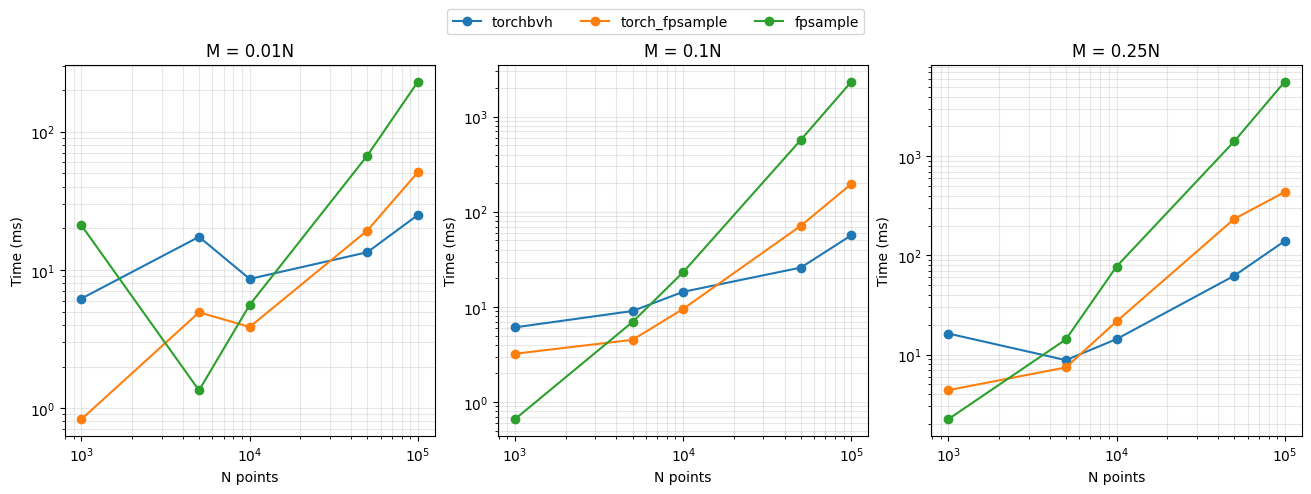

In [13]:
import matplotlib.pyplot as plt

FPS_SWEEP_SIZES = [1_000, 5_000, 10_000, 50_000, 100_000]
SWEEP_BATCH_SIZE = 1
FPS_SWEEP_RATIOS = [0.01, 0.1, 0.25]


def fps_sweep_quality(indices: torch.Tensor) -> dict:
    return {"shape": "x".join(map(str, indices.shape))}


def run_fps_sweep() -> list[dict]:
    global BATCH_SIZE, N_POINTS, N_QUERIES, FPS_TARGET, points, queries

    saved = {name: globals()[name] for name in ("BATCH_SIZE", "N_POINTS", "N_QUERIES", "FPS_TARGET", "points", "queries")}
    rows = []
    try:
        for ratio in FPS_SWEEP_RATIOS:
            for n in FPS_SWEEP_SIZES:
                BATCH_SIZE = SWEEP_BATCH_SIZE
                N_POINTS = n
                N_QUERIES = n
                FPS_TARGET = int(n * ratio)
                points, queries = make_data()
                sync()

                size_rows = run_backends(FPS_BACKENDS, "fps_sweep", fps_sweep_quality, warmup=WARMUP, iters=ITERS)
                for row in size_rows:
                    row["n"] = n
                    row["m"] = FPS_TARGET
                    row["m_ratio"] = ratio
                rows.extend(size_rows)
    finally:
        globals().update(saved)
        sync()
    return rows


fps_sweep_rows = show_rows(run_fps_sweep())

fig, axes = plt.subplots(1, len(FPS_SWEEP_RATIOS), figsize=(13, 4.5), sharey=False, constrained_layout=True)
if len(FPS_SWEEP_RATIOS) == 1:
    axes = [axes]

handles = []
labels = []
for ax, ratio in zip(axes, FPS_SWEEP_RATIOS):
    for label in FPS_BACKENDS:
        series = [
            row for row in fps_sweep_rows
            if row["backend"] == label and row.get("status") == "ok" and row["m_ratio"] == ratio
        ]
        if not series:
            continue
        line = ax.plot([row["n"] for row in series], [row["mean_ms"] for row in series], marker="o", label=label)[0]
        if label not in labels:
            handles.append(line)
            labels.append(label)
    ax.set_xlabel("N points")
    ax.set_ylabel("Time (ms)")
    ax.set_title(f"M = {ratio:g}N")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)

fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.08))
plt.show()
